Loading data...
Data loaded successfully!
X shape: (7440, 6020)
y shape: (7440,)
Unique emotions: ['ANG' 'DIS' 'FEA' 'HAP' 'NEU' 'SAD']

Emotion distribution:
  ANG: 1037 (13.9%)
  DIS: 648 (8.7%)
  FEA: 717 (9.6%)
  HAP: 393 (5.3%)
  NEU: 4208 (56.6%)
  SAD: 437 (5.9%)

Label mapping:
  ANG -> 0
  DIS -> 1
  FEA -> 2
  HAP -> 3
  NEU -> 4
  SAD -> 5

Train size: 5952
Test size: 1488

TRAINING RESULTS

Training Logistic Regression... ✓ Accuracy: 0.5269

Training KNN (k=3)... ✓ Accuracy: 0.5766

Training KNN (k=5)... ✓ Accuracy: 0.6001

Training KNN (k=7)... ✓ Accuracy: 0.6028

Training Decision Tree... ✓ Accuracy: 0.5376

Training Random Forest (50)... ✓ Accuracy: 0.6431

Training Random Forest (100)... ✓ Accuracy: 0.6438

Training Random Forest (200)... ✓ Accuracy: 0.6445

Training SVM (RBF)... ✓ Accuracy: 0.6425

Training SVM (Linear)... ✓ Accuracy: 0.5403

Training LDA... ✓ Accuracy: 0.1492

Training QDA... ✗ Error: The covariance matrix of class 0 is not full rank. When usin

SUMMA

C:\Users\test\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\test\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\test\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

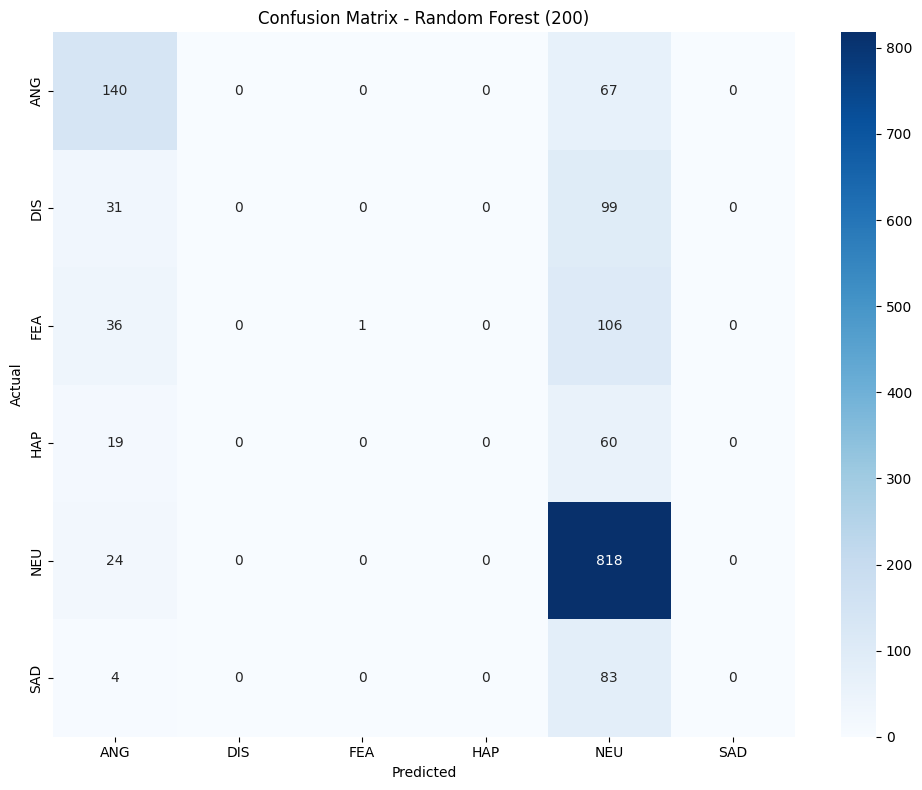

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
print("Loading data...")
data = np.load('crema_data.npz')  # or 'crema_data_cleaned.npz'

# Extract features and labels
X = data['features']      # Features matrix
y = data['emotions']      # Emotion labels
filenames = data['filenames']  # Filenames (if you saved them)

print(f"Data loaded successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")
print(f"\nEmotion distribution:")
unique, counts = np.unique(y, return_counts=True)
for emotion, count in zip(unique, counts):
    print(f"  {emotion}: {count} ({count/len(y)*100:.1f}%)")

# Encode labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nLabel mapping:")
for emotion, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {emotion} -> {code}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Scale features (important for many models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest (50)': RandomForestClassifier(n_estimators=50, random_state=42),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (200)': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
}

# Train and evaluate
print("\n" + "="*70)
print("TRAINING RESULTS")
print("="*70)

results = []

for name, model in models.items():
    try:
        print(f"\nTraining {name}...", end=" ")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            'Model': name,
            'Accuracy': f'{acc:.4f}',
            'Accuracy_Value': acc
        })
        print(f"✓ Accuracy: {acc:.4f}")
        
    except Exception as e:
        print(f"✗ Error: {str(e)[:60]}")
        results.append({
            'Model': name,
            'Accuracy': 'Error',
            'Accuracy_Value': 0
        })

# Summary
print("\n" + "="*70)
print("SUMMARY - SORTED BY ACCURACY")
print("="*70)
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('Accuracy_Value', ascending=False)
print(results_df_sorted[['Model', 'Accuracy']].to_string(index=False))

# Best model
best = results_df_sorted.iloc[0]
print(f"\n🏆 BEST MODEL: {best['Model']} with accuracy {best['Accuracy']}")

# Train best model again and show detailed results
best_model_name = best['Model']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print(f"\n" + "="*70)
print(f"DETAILED RESULTS FOR BEST MODEL: {best_model_name}")
print("="*70)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()